# 02.6 -- Does the TopoAE's persistent-homology instrument actually work? A Swiss roll sanity check

CLAUDE.md's rule in its own terms: a model that fails on real data has two possible causes --
the data has no structure to find, or the implementation is broken -- and only a manifold
whose answer is known in advance separates the two. Here the *model* (a `cae.PlainAutoEncoder`
trained under `topoae.train_topoae`'s topological loss) is not new -- it has already passed its
own Swiss roll check in `02.4_swiss_roll_topoae_check.ipynb` -- but the *instrument* is: this is
the first time `persistence_probe.readout_matrix`, the persistent-homology agreement criterion
ratified in `02.6-SCREENING-RULE-02.md`, is run on this trained decoder rather than on
known-answer fixtures. This notebook is what establishes that a persistent-homology number
computed on this model means what it is read as.

This notebook is the sibling to `02.6_swiss_roll_plainae_ph_check.ipynb` (Task 1): the same
15-cell structure, the same constants, the same held-out subsample and provenance recipe, and
the same read-out matrix and read-out cells, with exactly three changes -- the training loss in
§3, a genuinely matched plain-AE baseline carried through §4 and §6, and §7's boolean (d)
comparing against both that baseline and the chance null.

Bars inside this notebook are **absolute**, because the roll's answer is exact (D-07). The PU
side of this phase's screen is comparative instead -- against a matched baseline and a null --
and belongs to a different arm (`notebooks/diagnostics/decoder_substrate_ph_screen_run.py`)
entirely.


## §1. Setup

In [1]:
import sys
import time
from pathlib import Path

# import pu_manifold exactly as the other notebooks do -- relative, never from src/effdim/
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

t_notebook_start = time.time()

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import spearmanr
from sklearn.datasets import make_swiss_roll

from pu_manifold import analytic_param, cae, persistence_probe, topoae

SEED = 0                    # torch / split seed
FIXTURE_SEED = 20260807     # the roll's own generation seed -- fixed across this phase
N_POINTS = 3000
LATENT_DIM = 2               # the roll's true intrinsic dimension
HIDDEN = (64, 64, 64)
CFG = dict(seed=SEED, lr=3e-4, weight_decay=1e-4, batch=64, max_epochs=150)
LAMBDA_TOPO = 0.1
WARMUP_FRAC = 0.25
RAMP_FRAC = 0.25
PRESCALE = True               # ratified Q1: symmetric per-cloud pre-scaling via topoae.latent_unit_scale
VIEW = dict(elev=12, azim=-78)  # looks along the roll's extrusion axis, so the spiral shows

# persim.wasserstein's exact matching over sealed persistence_probe.py's H0 diagrams is O(n^3)
# in the number of finite pairs (measured: ~2s at 200 points, ~30s at 599 points, on real
# cloud birth/death values -- not a synthetic worst case). At the full 600-point holdout (80/20
# of N_POINTS) this notebook would need TWELVE H0 Wasserstein calls (TopoAE arm, matched plain-AE
# baseline, chance null -- four each), blowing CLAUDE.md's two-minute budget many times over.
# Sec. 6's persistence read-out is therefore computed on a smaller, fixed subsample of the
# held-out rows (PH_N_HOLDOUT of the full holdout, drawn deterministically) -- every other
# section (reconstruction, latent scatter, Spearman) still uses the full held-out set below.
PH_N_HOLDOUT = 150

print(f"torch {torch.__version__}  numpy {np.__version__}")
print(f"persistence_probe module: {persistence_probe.__file__}")
print(
    "Reproducibility note: ripser and persim are not declared in pyproject.toml -- CLAUDE.md "
    "bars editing it for the whole v1.1 milestone -- so they must already be installed into "
    "this repository's venv by hand. Presence is confirmed here by the import above "
    "succeeding, never by shelling out to a package manager."
)


torch 2.13.0+cpu  numpy 2.5.1
persistence_probe module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/persistence_probe.py
Reproducibility note: ripser and persim are not declared in pyproject.toml -- CLAUDE.md bars editing it for the whole v1.1 milestone -- so they must already be installed into this repository's venv by hand. Presence is confirmed here by the import above succeeding, never by shelling out to a package manager.


## §2. The roll and its two references

X (3000, 3)  train 2400  holdout 600


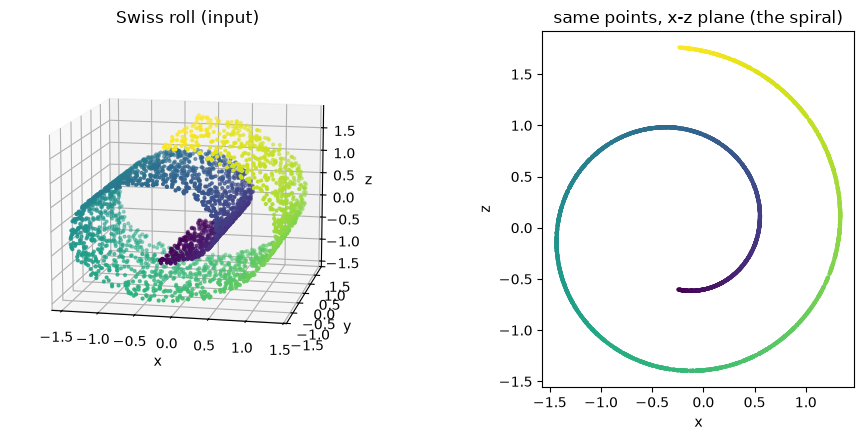


Reference provenance (this notebook's own held-out subsample, n_holdout=600, prescale=False -- matches 02.6-SCREENING-RULE-02.md's own illustrative recipe):


  intrinsic H0: n_features=599  top_life=0.3748  own_diameter=11.3425  ref_max_persistence(denominator)=0.3748  applied_scale=1.0000
  intrinsic H1: n_features=148  top_life=0.4001  own_diameter=11.3425  ref_max_persistence(denominator)=0.4001  applied_scale=1.0000


  ambient H0: n_features=599  top_life=0.3743  own_diameter=4.0417  ref_max_persistence(denominator)=0.3743  applied_scale=1.0000
  ambient H1: n_features=258  top_life=0.7263  own_diameter=4.0417  ref_max_persistence(denominator)=0.7263  applied_scale=1.0000


  between-references H1 bottleneck: 0.36313  ambient-reference own saturation value: 0.36313  saturated=True
  Citing the 'Bottleneck saturation' travelling caveat by name (02.6-SCREENING-RULE-02.md): the (H1, ambient) bottleneck cell below is expected to sit at this same saturation value for any candidate whose latent has correctly unrolled the roll -- a saturated cell is reported with its flag and is never read as a measurement, not before, and not after, any model number appears.


In [2]:
X_raw, t = make_swiss_roll(n_samples=N_POINTS, noise=0.0, random_state=FIXTURE_SEED)
global_std = float(X_raw.std())
X = (X_raw - X_raw.mean(axis=0)) / global_std  # one global scalar -- shape preserved

rng = np.random.default_rng(SEED)
perm = rng.permutation(N_POINTS)
n_train = int(0.8 * N_POINTS)
train_idx, holdout_idx = perm[:n_train], perm[n_train:]

x_all = torch.tensor(X, dtype=torch.float32)
x_train = x_all[train_idx]
x_holdout = x_all[holdout_idx]
t_holdout = t[holdout_idx]

print(f"X {X.shape}  train {len(train_idx)}  holdout {len(holdout_idx)}")

# D-03's two references, built on the SAME held-out row indices as the model's own latent
# and decoder image below (T-02.6R-17 -- mismatched references would compare different
# subsets of the manifold).
intrinsic_ref_holdout = analytic_param.swiss_roll_intrinsic_plane(
    t_holdout, X[holdout_idx, 1], global_std
)
ambient_ref_holdout = X[holdout_idx]

fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=4)
ax.view_init(**VIEW)
ax.set_title("Swiss roll (input)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[:, 0], X[:, 2], c=t, cmap="viridis", s=4)
ax2.set_title("same points, x-z plane (the spiral)")
ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

# Reference provenance -- printed BEFORE any model number, per the two travelling caveats
# (02.6-SCREENING-RULE-02.md). prescale=False here: this is the illustrative, no-pre-scaling
# recipe the ratification document itself uses to state the caveats' figures.
print()
print("Reference provenance (this notebook's own held-out subsample, n_holdout="
      f"{len(holdout_idx)}, prescale=False -- matches 02.6-SCREENING-RULE-02.md's own "
      "illustrative recipe):")
ref_diagrams = {}
for name, cloud in (("intrinsic", intrinsic_ref_holdout), ("ambient", ambient_ref_holdout)):
    D, scale = persistence_probe.cloud_distance_matrix(cloud, prescale=False)
    dgms = persistence_probe.persistence_diagram(D)
    ref_diagrams[name] = dgms
    diameter = float(D.max())
    for k, degree in enumerate(("H0", "H1")):
        dgm = dgms[k]
        top_life = persistence_probe.max_persistence(dgm)
        print(
            f"  {name} {degree}: n_features={dgm.shape[0]}  top_life={top_life:.4f}  "
            f"own_diameter={diameter:.4f}  ref_max_persistence(denominator)={top_life:.4f}  "
            f"applied_scale={scale:.4f}"
        )

h1_agreement = persistence_probe.ph_agreement(ref_diagrams["intrinsic"][1], ref_diagrams["ambient"][1])
ambient_h1_saturation = persistence_probe.saturation_value(ref_diagrams["ambient"][1])
print(
    f"  between-references H1 bottleneck: {h1_agreement['bottleneck']:.5f}  "
    f"ambient-reference own saturation value: {ambient_h1_saturation:.5f}  "
    f"saturated={h1_agreement['saturated']}"
)
print(
    "  Citing the 'Bottleneck saturation' travelling caveat by name "
    "(02.6-SCREENING-RULE-02.md): the (H1, ambient) bottleneck cell below is expected to sit "
    "at this same saturation value for any candidate whose latent has correctly unrolled the "
    "roll -- a saturated cell is reported with its flag and is never read as a measurement, "
    "not before, and not after, any model number appears."
)


## §3. Fit the TopoAE arm

**Change 1 from the plain-AE notebook.** The TopoAE arm is `cae.PlainAutoEncoder` -- the
IDENTICAL architecture as Task 1's model -- trained under `topoae.train_topoae`'s topological
loss instead of plain MSE reconstruction. It is a plain autoencoder trained under a different
loss, never a different architecture -- the point of this phase's comparison is the loss, not
the capacity.

epochs_run    = 150
wallclock_s   = 37.6
early_stopped = False


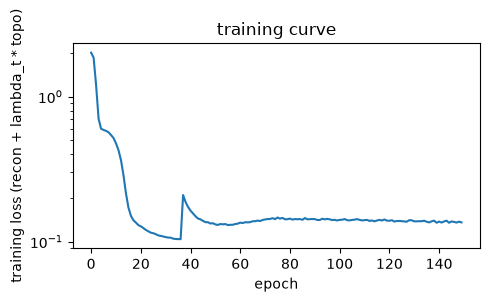

In [3]:
torch.manual_seed(SEED)
model = cae.PlainAutoEncoder(3, LATENT_DIM, hidden=HIDDEN, activation="silu")
topoae_cfg = dict(
    seed=SEED,
    lambda_topo=LAMBDA_TOPO,
    warmup_frac=WARMUP_FRAC,
    ramp_frac=RAMP_FRAC,
    lr=CFG["lr"], weight_decay=CFG["weight_decay"], batch=CFG["batch"], max_epochs=CFG["max_epochs"],
)
fit = topoae.train_topoae(model, x_train, topoae_cfg)
model.eval()

print(f"epochs_run    = {fit['epochs_run']}")
print(f"wallclock_s   = {fit['wallclock_s']:.1f}")
print(f"early_stopped = {fit['early_stopped']}")

main_history = [h for h in fit["history"] if h["stage"] == "main"]
plt.figure(figsize=(5, 3))
plt.plot([h["epoch"] for h in main_history], [h["total"] for h in main_history])
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("training loss (recon + lambda_t * topo)")
plt.title("training curve")
plt.tight_layout()
plt.show()


## §4. The reconstruction, side by side

**Change 2 from the plain-AE notebook.** Here the model under test is NOT `cae.PlainAutoEncoder`
itself, so CLAUDE.md's named matched baseline applies literally: a separate
`cae.PlainAutoEncoder` at the identical width, depth, protocol and 2-D bottleneck, trained under
plain `cae.train_plain_ae` with the identical `CFG` -- the same model Task 1's notebook trained,
retrained here from the same seed for a self-contained comparison.

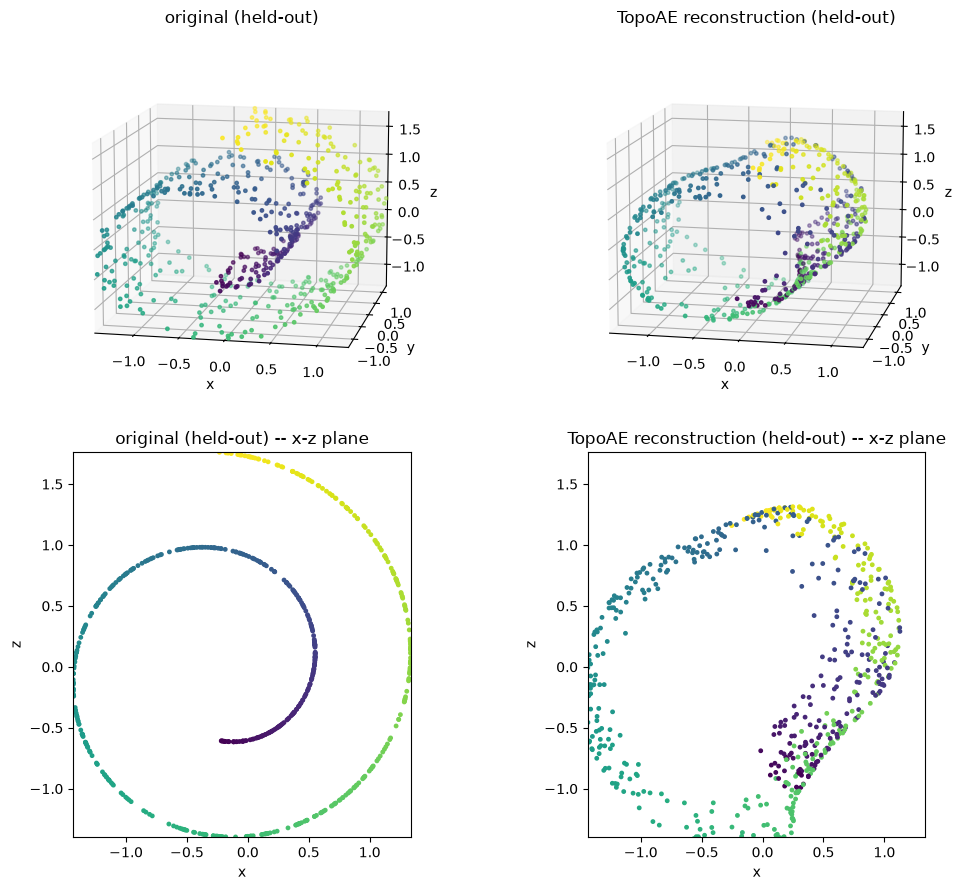

=== held-out reconstruction ===
TopoAE arm                        mse_per_dim = 0.034817
matched plain-AE baseline (d=2)       mse_per_dim = 0.021583
TopoAE arm mean relative error     = 0.2278  (22.8% of point norm)
baseline epochs_run=150  wallclock_s=14.1


In [4]:
with torch.no_grad():
    y_holdout = model(x_holdout)["y"]
    z_train = model.encode(x_train)
    z_holdout = model.encode(x_holdout)

y_holdout_np = y_holdout.numpy()

fig = plt.figure(figsize=(11, 9))
for i, (data, title) in enumerate([(X[holdout_idx], "original (held-out)"), (y_holdout_np, "TopoAE reconstruction (held-out)")]):
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=t_holdout, cmap="viridis", s=6)
    ax.view_init(**VIEW)
    ax.set_title(title)
    ax.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax.set_ylim(X[:, 1].min(), X[:, 1].max())
    ax.set_zlim(X[:, 2].min(), X[:, 2].max())
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

    ax2 = fig.add_subplot(2, 2, i + 3)
    ax2.scatter(data[:, 0], data[:, 2], c=t_holdout, cmap="viridis", s=6)
    ax2.set_title(f"{title} -- x-z plane")
    ax2.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax2.set_ylim(X[:, 2].min(), X[:, 2].max())
    ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

recon_stats = cae.reconstruction_stats(x_holdout.double(), y_holdout.double())
rel_err = float(
    (torch.linalg.vector_norm(x_holdout - y_holdout, dim=-1)
     / torch.linalg.vector_norm(x_holdout, dim=-1)).mean()
)

# CLAUDE.md's matched baseline, trained literally: same width/depth/protocol/bottleneck, plain
# MSE reconstruction loss, identical CFG, identical seed.
torch.manual_seed(SEED)
baseline = cae.PlainAutoEncoder(3, LATENT_DIM, hidden=HIDDEN, activation="silu")
baseline_fit = cae.train_plain_ae(baseline, x_train, CFG)
baseline.eval()
with torch.no_grad():
    y_holdout_baseline = baseline(x_holdout)["y"]
    z_train_baseline = baseline.encode(x_train)
    z_holdout_baseline = baseline.encode(x_holdout)
baseline_stats = cae.reconstruction_stats(x_holdout.double(), y_holdout_baseline.double())

print("=== held-out reconstruction ===")
print(f"TopoAE arm                        mse_per_dim = {recon_stats['mse_per_dim']:.6f}")
print(f"matched plain-AE baseline (d={LATENT_DIM})       mse_per_dim = {baseline_stats['mse_per_dim']:.6f}")
print(f"TopoAE arm mean relative error     = {rel_err:.4f}  ({100 * rel_err:.1f}% of point norm)")
print(f"baseline epochs_run={baseline_fit['epochs_run']}  wallclock_s={baseline_fit['wallclock_s']:.1f}")


## §5. The latent -- did the spiral unroll?

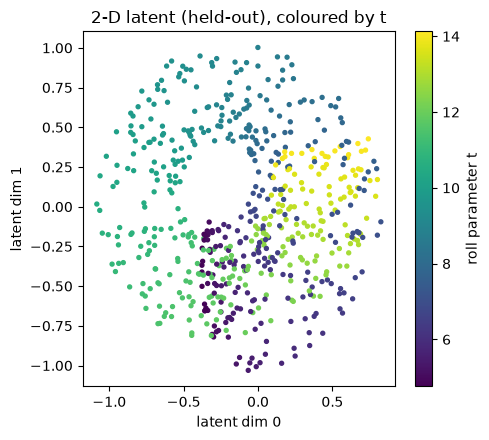

Spearman(latent PC1, t) = -0.1373  (p=7.46e-04)
|Spearman| = 0.1373


In [5]:
z_holdout_np = z_holdout.double().numpy()

plt.figure(figsize=(5, 4.5))
sc = plt.scatter(z_holdout_np[:, 0], z_holdout_np[:, 1], c=t_holdout, cmap="viridis", s=8)
plt.colorbar(sc, label="roll parameter t")
plt.title("2-D latent (held-out), coloured by t")
plt.xlabel("latent dim 0"); plt.ylabel("latent dim 1")
plt.tight_layout()
plt.show()

# First principal coordinate of the latent -- colour bands staying in order is exactly what
# a monotone rank correlation against t measures, making CLAUDE.md's visual check checkable.
z_centered = z_holdout_np - z_holdout_np.mean(axis=0, keepdims=True)
_, _, Vt = np.linalg.svd(z_centered, full_matrices=False)
latent_pc1 = z_centered @ Vt[0]

spearman_r, spearman_p = spearmanr(latent_pc1, t_holdout)
print(f"Spearman(latent PC1, t) = {spearman_r:.4f}  (p={spearman_p:.2e})")
print(f"|Spearman| = {abs(spearman_r):.4f}")


## §6. Persistence agreement, this seed

**Change 2 continues here.** The matched plain-AE baseline's own 16-cell read-out is reported
beside the TopoAE arm's and beside the chance null's -- three labelled blocks, every number
kept separate, no ratio column and no combined figure between them.

In [6]:
decoder_image_holdout = y_holdout_np.astype(np.float64)
decoder_image_holdout_baseline = y_holdout_baseline.numpy().astype(np.float64)

# Fixed subsample of the held-out rows for the persistence computation only (see the
# PH_N_HOLDOUT note in §1) -- the SAME row subset feeds all clouds below, so
# space-vs-reference comparisons stay index-consistent (T-02.6R-17).
ph_sub = np.random.default_rng(SEED).permutation(len(holdout_idx))[:PH_N_HOLDOUT]
print(f"Persistence read-out computed on a {PH_N_HOLDOUT}-row subsample of the "
      f"{len(holdout_idx)}-row holdout (wall-clock budget; see §1).")

references = {"intrinsic": intrinsic_ref_holdout[ph_sub], "ambient": ambient_ref_holdout[ph_sub]}


def print_readout(label, readout):
    print(f"=== {label} -- all 16 read-out cells (PRESCALE={PRESCALE}) ===")
    for cell in persistence_probe.READOUT_CELLS:
        space, reference, hk, _ = cell.split("|")
        raw_key = cell.replace("_norm", "_raw")
        denom_key = f"{reference}|{hk}|ref_max_persistence"
        sat_key = f"{space}|{reference}|{hk}|saturated"
        print(
            f"  {cell:42s} norm={readout[cell]:9.4f}  raw={readout[raw_key]:9.4f}  "
            f"denom={readout[denom_key]:7.4f}  saturated={readout[sat_key]}"
        )


# Block 1 -- the TopoAE arm.
spaces = {"latent": z_holdout_np[ph_sub], "decoder_image": decoder_image_holdout[ph_sub]}
readout = persistence_probe.readout_matrix(spaces, references, PRESCALE)
print_readout(f"TopoAE arm, seed={SEED}", readout)

# Block 2 -- the matched plain-AE baseline (Change 2).
z_holdout_baseline_np = z_holdout_baseline.double().numpy()
spaces_baseline = {
    "latent": z_holdout_baseline_np[ph_sub],
    "decoder_image": decoder_image_holdout_baseline[ph_sub],
}
readout_baseline = persistence_probe.readout_matrix(spaces_baseline, references, PRESCALE)
print()
print_readout(f"matched plain-AE baseline, seed={SEED}", readout_baseline)

# Block 3 -- the chance null every persistent-homology number needs to be read against: a
# seeded random cloud, same row count, same latent dimension, scaled the same way (PRESCALE
# threaded through readout_matrix identically). No decoder exists for a null cloud, so the same
# null array stands in for both the "latent" and "decoder_image" slots readout_matrix requires.
null_rng = np.random.default_rng(SEED + 100)
null_cloud = null_rng.standard_normal((PH_N_HOLDOUT, LATENT_DIM))
null_spaces = {"latent": null_cloud, "decoder_image": null_cloud}
null_readout = persistence_probe.readout_matrix(null_spaces, references, PRESCALE)
print()
print_readout(f"chance null, seed={SEED + 100}", null_readout)


Persistence read-out computed on a 150-row subsample of the 600-row holdout (wall-clock budget; see §1).


=== TopoAE arm, seed=0 -- all 16 read-out cells (PRESCALE=True) ===
  latent|intrinsic|H0|bottleneck_norm        norm=   0.7721  raw=   0.2846  denom= 0.3686  saturated=False
  latent|intrinsic|H0|wasserstein_norm       norm=  24.3549  raw=   8.9765  denom= 0.3686  saturated=False
  latent|intrinsic|H1|bottleneck_norm        norm=   1.1506  raw=   0.2352  denom= 0.2044  saturated=False
  latent|intrinsic|H1|wasserstein_norm       norm=   9.1295  raw=   1.8664  denom= 0.2044  saturated=False
  latent|ambient|H0|bottleneck_norm          norm=   0.3785  raw=   0.3480  denom= 0.9193  saturated=False
  latent|ambient|H0|wasserstein_norm         norm=  25.0220  raw=  23.0028  denom= 0.9193  saturated=False
  latent|ambient|H1|bottleneck_norm          norm=   0.5000  raw=   0.4036  denom= 0.8072  saturated=True
  latent|ambient|H1|wasserstein_norm         norm=   5.7285  raw=   4.6243  denom= 0.8072  saturated=True
  decoder_image|intrinsic|H0|bottleneck_norm norm=   0.9438  raw=   0.3479  de


=== matched plain-AE baseline, seed=0 -- all 16 read-out cells (PRESCALE=True) ===
  latent|intrinsic|H0|bottleneck_norm        norm=   0.8475  raw=   0.3124  denom= 0.3686  saturated=False
  latent|intrinsic|H0|wasserstein_norm       norm=  17.4611  raw=   6.4356  denom= 0.3686  saturated=False
  latent|intrinsic|H1|bottleneck_norm        norm=   0.7808  raw=   0.1596  denom= 0.2044  saturated=False
  latent|intrinsic|H1|wasserstein_norm       norm=   7.3844  raw=   1.5096  denom= 0.2044  saturated=False
  latent|ambient|H0|bottleneck_norm          norm=   0.3175  raw=   0.2919  denom= 0.9193  saturated=False
  latent|ambient|H0|wasserstein_norm         norm=  26.9940  raw=  24.8157  denom= 0.9193  saturated=False
  latent|ambient|H1|bottleneck_norm          norm=   0.5000  raw=   0.4036  denom= 0.8072  saturated=True
  latent|ambient|H1|wasserstein_norm         norm=   5.8301  raw=   4.7063  denom= 0.8072  saturated=True
  decoder_image|intrinsic|H0|bottleneck_norm norm=   0.9416  r


=== chance null, seed=100 -- all 16 read-out cells (PRESCALE=True) ===
  latent|intrinsic|H0|bottleneck_norm        norm=   1.3345  raw=   0.4919  denom= 0.3686  saturated=False
  latent|intrinsic|H0|wasserstein_norm       norm=  38.2467  raw=  14.0966  denom= 0.3686  saturated=False
  latent|intrinsic|H1|bottleneck_norm        norm=   0.7663  raw=   0.1567  denom= 0.2044  saturated=False
  latent|intrinsic|H1|wasserstein_norm       norm=   8.9333  raw=   1.8263  denom= 0.2044  saturated=False
  latent|ambient|H0|bottleneck_norm          norm=   0.2173  raw=   0.1998  denom= 0.9193  saturated=False
  latent|ambient|H0|wasserstein_norm         norm=  19.2161  raw=  17.6654  denom= 0.9193  saturated=False
  latent|ambient|H1|bottleneck_norm          norm=   0.5000  raw=   0.4036  denom= 0.8072  saturated=True
  latent|ambient|H1|wasserstein_norm         norm=   6.3728  raw=   5.1444  denom= 0.8072  saturated=True
  decoder_image|intrinsic|H0|bottleneck_norm norm=   1.3345  raw=   0.4919

## §7. Read-out

**Change 3.** Booleans (a), (b) and (c) are unchanged from the plain-AE notebook. Boolean (d)
now compares the TopoAE arm against BOTH the matched plain-AE baseline and the chance null.

In [7]:
recon_ok = rel_err < 0.10
unrolled_ok = abs(spearman_r) > 0.90
signature_ok = (
    readout["latent|intrinsic|H1|wasserstein_raw"] < readout["latent|ambient|H1|wasserstein_raw"]
)
beats_baseline_and_null_ok = (
    readout["latent|intrinsic|H0|wasserstein_raw"] < readout_baseline["latent|intrinsic|H0|wasserstein_raw"]
    and readout["latent|intrinsic|H1|wasserstein_raw"] < readout_baseline["latent|intrinsic|H1|wasserstein_raw"]
    and readout["latent|intrinsic|H0|wasserstein_raw"] < null_readout["latent|intrinsic|H0|wasserstein_raw"]
    and readout["latent|intrinsic|H1|wasserstein_raw"] < null_readout["latent|intrinsic|H1|wasserstein_raw"]
)

print(f"(a) roll reconstructed (held-out rel. err < 0.10)         : {recon_ok}   ({100 * rel_err:.1f}%)")
print(f"(b) spiral unrolled (|Spearman(latent PC1, t)| > 0.90)    : {unrolled_ok}   ({abs(spearman_r):.4f})")
print(
    "(c) D-03 signature holds (H1-to-intrinsic < H1-to-ambient) : "
    f"{signature_ok}   ({readout['latent|intrinsic|H1|wasserstein_raw']:.4f} vs "
    f"{readout['latent|ambient|H1|wasserstein_raw']:.4f})"
)
print(
    "(d) beats BOTH the matched plain-AE baseline AND the null  : "
    f"{beats_baseline_and_null_ok}"
)
print(
    f"    TopoAE H0={readout['latent|intrinsic|H0|wasserstein_raw']:.4f}  "
    f"baseline H0={readout_baseline['latent|intrinsic|H0|wasserstein_raw']:.4f}  "
    f"null H0={null_readout['latent|intrinsic|H0|wasserstein_raw']:.4f}"
)
print(
    f"    TopoAE H1={readout['latent|intrinsic|H1|wasserstein_raw']:.4f}  "
    f"baseline H1={readout_baseline['latent|intrinsic|H1|wasserstein_raw']:.4f}  "
    f"null H1={null_readout['latent|intrinsic|H1|wasserstein_raw']:.4f}"
)

elapsed_s = time.time() - t_notebook_start
print()
print(f"total wall clock: {elapsed_s:.1f}s")
print()

if recon_ok and unrolled_ok and signature_ok and beats_baseline_and_null_ok:
    print(
        "The TopoAE arm reconstructs the roll, its latent unrolls the spiral with colour "
        "order intact, the H1 signature D-03 predicts for a correct unroll holds, and it "
        "clearly beats both the matched plain-AE baseline and a chance null -- this notebook "
        "licenses reading a persistence-agreement number on this model as a real measurement "
        "of the instrument. The two effect sizes this phase must argue against: the largest "
        "measured difference so far is single-chart vs multi-chart at about 3.4x on H0 "
        "retention, while the topological-loss axis is worth about 6% -- a difference inside "
        "that 6% is arguing inside it, and per A-02 none of this speaks to curvature fidelity "
        "on its own."
    )
else:
    print(
        "At least one line above is False. Per CLAUDE.md that is a real result, reported "
        "plainly: if the TopoAE arm is not clearly better than the matched plain baseline on a "
        "manifold its loss was designed for, that is a real result about the model, not a "
        "notebook defect -- and it must be weighed against the two effect sizes this phase "
        "must argue against: the largest measured difference so far is single-chart vs "
        "multi-chart at about 3.4x on H0 retention, while the topological-loss axis is worth "
        "about 6%, so a difference living inside that 6% is arguing inside it."
    )


(a) roll reconstructed (held-out rel. err < 0.10)         : False   (22.8%)
(b) spiral unrolled (|Spearman(latent PC1, t)| > 0.90)    : False   (0.1373)
(c) D-03 signature holds (H1-to-intrinsic < H1-to-ambient) : True   (1.8664 vs 4.6243)
(d) beats BOTH the matched plain-AE baseline AND the null  : False
    TopoAE H0=8.9765  baseline H0=6.4356  null H0=14.0966
    TopoAE H1=1.8664  baseline H1=1.5096  null H1=1.8263

total wall clock: 74.3s

At least one line above is False. Per CLAUDE.md that is a real result, reported plainly: if the TopoAE arm is not clearly better than the matched plain baseline on a manifold its loss was designed for, that is a real result about the model, not a notebook defect -- and it must be weighed against the two effect sizes this phase must argue against: the largest measured difference so far is single-chart vs multi-chart at about 3.4x on H0 retention, while the topological-loss axis is worth about 6%, so a difference living inside that 6% is arguing in